# ichorCNA Precision Audit

This notebook investigates two concerns raised during manuscript preparation:

1. **Duplicate samples in the aggregate CSV** — `cris_stage_vaf_coverage_ichor_aggregate.csv` has 550 rows vs 534 samples in `cris_metadata.csv`. Are there duplicate entries?
2. **ichorCNA TF values for healthy samples** — are healthy samples truly TF = 0, or does ichorCNA assign a non-zero baseline? This is relevant for understanding precision at the 95% specificity threshold.

TF values are read **directly from `results/ichorCNA/*/params.txt`** (the raw ichorCNA output) — not from the aggregate CSV — to rule out any CSV-level corruption.

In [1]:
import glob
import os
import re
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, auc, confusion_matrix, roc_auc_score

# Working directory should be u:/KWFcfDNA/emc/comp
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('')))
print('Working dir:', os.getcwd())

Working dir: u:\KWFcfDNA\emc\comp


## 1. Read ichorCNA TF values directly from raw params files

In [2]:
def parse_params_file(path):
    """Extract Tumor Fraction from an ichorCNA *.params.txt file."""
    with open(path) as fh:
        for line in fh:
            m = re.match(r'^Tumor Fraction:\s+([\d\.]+)', line)
            if m:
                return float(m.group(1))
    return np.nan


params_files = glob.glob('results/ichorCNA/*/*.params.txt')
print(f'Found {len(params_files)} params files')

records = []
for path in params_files:
    # Folder name is like EE87790.hg38.frag.tsv
    sample_dir = os.path.basename(os.path.dirname(path))
    sample_id = sample_dir.split('.')[0]  # EE87790
    tf = parse_params_file(path)
    records.append({'ID': sample_id, 'ichorcna_tf_raw': tf})

raw_tf_df = pd.DataFrame(records)
print(f'Parsed {len(raw_tf_df)} samples, NaN TF: {raw_tf_df["ichorcna_tf_raw"].isna().sum()}')
raw_tf_df.head()

Found 534 params files
Parsed 534 samples, NaN TF: 0


,ID,ichorcna_tf_raw
0,EE87791,0.01484
1,EE87790,0.02236
2,EE87792,0.01662
3,EE87793,0.01487
4,EE87794,0.01869


## 2. Merge raw TF with metadata

In [3]:
metadata = pd.read_csv('accessory_files/cris_metadata.csv')
print('Metadata shape:', metadata.shape)
print('Disease counts:')
print(metadata['disease'].value_counts().to_string())

df = metadata.merge(raw_tf_df, on='ID', how='left')
print(f'\nAfter merge: {len(df)} rows')
print(f'Samples missing params file: {df["ichorcna_tf_raw"].isna().sum()}')
df[['ID', 'disease', 'ichorcna_tf_raw']].head()

Metadata shape: (534, 11)
Disease counts:
disease
Healthy                    262
Lung cancer                 67
Breast cancer               54
Pancreatic cancer           35
Ovarian cancer              28
Gastric cancer              27
Colorectal cancer           26
Bile duct cancer            24
Lung cancer naive nsclc     10
Duodenal cancer              1

After merge: 534 rows
Samples missing params file: 4


,ID,disease,ichorcna_tf_raw
0,EE87786,Bile duct cancer,NaN
1,EE87787,Bile duct cancer,NaN
2,EE87788,Bile duct cancer,NaN
3,EE87789,Bile duct cancer,NaN
4,EE87790,Bile duct cancer,0.02236


## 3. Check for duplicates in the aggregate CSV

In [4]:
agg = pd.read_csv('accessory_files/cris_stage_vaf_coverage_ichor_aggregate.csv', index_col=0)

print('=== Aggregate CSV ===')
print(f'Rows: {len(agg)}')
print(f'Unique IDs: {agg["ID"].nunique()}')
print(f'Duplicate IDs: {agg["ID"].duplicated().sum()}')
print()

dups = agg[agg['ID'].duplicated(keep=False)].sort_values('ID')
print(f'Duplicated rows ({len(dups)} rows = {len(dups)//2} duplicate pairs):')
print(dups[['ID', 'disease', 'ichorcna_tf']].to_string())
print()

print('=== Disease counts in aggregate CSV (with duplicates) ===')
print(agg['disease'].value_counts().to_string())
print()
print('=== Disease counts in metadata (ground truth) ===')
print(metadata['disease'].value_counts().to_string())

=== Aggregate CSV ===
Rows: 550
Unique IDs: 534
Duplicate IDs: 16

Duplicated rows (32 rows = 16 duplicate pairs):
                 ID  disease  ichorcna_tf
Unnamed: 0                               
157         EE87946  Healthy      0.01667
158         EE87946  Healthy      0.01667
170         EE87958  Healthy      0.01436
171         EE87958  Healthy      0.01436
175         EE87962  Healthy      0.01502
176         EE87962  Healthy      0.01502
211         EE87997  Healthy      0.01712
212         EE87997  Healthy      0.01712
223         EE88008  Healthy      0.01666
224         EE88008  Healthy      0.01666
230         EE88014  Healthy      0.01680
231         EE88014  Healthy      0.01680
236         EE88019  Healthy      0.01155
237         EE88019  Healthy      0.01155
243         EE88024  Healthy      0.01649
242         EE88024  Healthy      0.01649
245         EE88026  Healthy      0.01803
246         EE88026  Healthy      0.01803
301         EE88081  Healthy      0.01628
302

In [5]:
# Verify: do the duplicate entries have identical TF values in the CSV vs raw params?
dup_ids = dups['ID'].unique()
comparison = df[df['ID'].isin(dup_ids)][['ID', 'disease', 'ichorcna_tf_raw']]
comparison = comparison.merge(
    agg[agg['ID'].isin(dup_ids)].drop_duplicates('ID')[['ID', 'ichorcna_tf']],
    on='ID'
)
comparison['tf_match'] = np.isclose(comparison['ichorcna_tf_raw'], comparison['ichorcna_tf'], atol=1e-5)
print('Duplicated samples: raw params TF vs aggregate CSV TF')
print(comparison[['ID', 'disease', 'ichorcna_tf_raw', 'ichorcna_tf', 'tf_match']].to_string())

Duplicated samples: raw params TF vs aggregate CSV TF
         ID  disease  ichorcna_tf_raw  ichorcna_tf  tf_match
0   EE87946  Healthy          0.01667      0.01667      True
1   EE87958  Healthy          0.01436      0.01436      True
2   EE87962  Healthy          0.01502      0.01502      True
3   EE87997  Healthy          0.01712      0.01712      True
4   EE88008  Healthy          0.01666      0.01666      True
5   EE88014  Healthy          0.01680      0.01680      True
6   EE88019  Healthy          0.01155      0.01155      True
7   EE88024  Healthy          0.01649      0.01649      True
8   EE88026  Healthy          0.01803      0.01803      True
9   EE88081  Healthy          0.01628      0.01628      True
10  EE88092  Healthy          0.01499      0.01499      True
11  EE88126  Healthy          0.01457      0.01457      True
12  EE88135  Healthy          0.01391      0.01391      True
13  EE88140  Healthy          0.01094      0.01094      True
14  EE88151  Healthy          0

## 4. Identify the study cohort (210 healthy + 80 cancer)

The nested CV (BRCA + CRC) uses 290 of the 534 samples. We identify which samples were actually used.

In [6]:
# Gather all test_sample_ids from the RNA nested CV results
rna_files = sorted(glob.glob('nested_cv_results_cris/brca_crc_rna/results*.pkl'))
print(f'Found {len(rna_files)} RNA result files')

study_ids = set()
for fp in rna_files:
    with open(fp, 'rb') as fh:
        result_df = pickle.load(fh)
    for ids in result_df['test_sample_ids']:
        study_ids.update(ids)

print(f'Total unique sample IDs across all nested CV folds: {len(study_ids)}')

study_meta = metadata[metadata['ID'].isin(study_ids)].copy()
print('\nStudy cohort disease distribution:')
print(study_meta['disease'].value_counts().to_string())

excluded_meta = metadata[~metadata['ID'].isin(study_ids)].copy()
print(f'\nExcluded from study ({len(excluded_meta)} samples):')
print(excluded_meta['disease'].value_counts().to_string())

Found 25 RNA result files
Total unique sample IDs across all nested CV folds: 290

Study cohort disease distribution:
disease
Healthy              210
Breast cancer         54
Colorectal cancer     26

Excluded from study (244 samples):
disease
Lung cancer                67
Healthy                    52
Pancreatic cancer          35
Ovarian cancer             28
Gastric cancer             27
Bile duct cancer           24
Lung cancer naive nsclc    10
Duodenal cancer             1


## 5. TF distribution: raw params, study cohort only

In [7]:
# Merge raw TF into study cohort
study_df = study_meta.merge(raw_tf_df, on='ID', how='left')

healthy_tf = study_df[study_df['disease'] == 'Healthy']['ichorcna_tf_raw']
brca_tf    = study_df[study_df['disease'] == 'Breast cancer']['ichorcna_tf_raw']
crc_tf     = study_df[study_df['disease'] == 'Colorectal cancer']['ichorcna_tf_raw']

print('=== Raw ichorCNA TF — study cohort only ===')
print(f'Healthy  (n={len(healthy_tf)}): mean={healthy_tf.mean():.4f}, '
      f'std={healthy_tf.std():.4f}, min={healthy_tf.min():.4f}, '
      f'median={healthy_tf.median():.4f}, max={healthy_tf.max():.4f}')
print(f'BRCA     (n={len(brca_tf)}): mean={brca_tf.mean():.4f}, '
      f'std={brca_tf.std():.4f}, min={brca_tf.min():.4f}, '
      f'median={brca_tf.median():.4f}, max={brca_tf.max():.4f}')
print(f'CRC      (n={len(crc_tf)}): mean={crc_tf.mean():.4f}, '
      f'std={crc_tf.std():.4f}, min={crc_tf.min():.4f}, '
      f'median={crc_tf.median():.4f}, max={crc_tf.max():.4f}')
print()
print(f'Healthy samples with TF == 0:     {(healthy_tf == 0).sum()} / {len(healthy_tf)}')
print(f'Healthy samples with TF > 0:      {(healthy_tf > 0).sum()} / {len(healthy_tf)}')
print(f'Healthy samples with TF > 0.02:   {(healthy_tf > 0.02).sum()} / {len(healthy_tf)}')
print(f'Cancer  samples with TF == 0:     {((brca_tf == 0).sum() + (crc_tf == 0).sum())} / {len(brca_tf)+len(crc_tf)}')
print(f'Cancer  samples with TF > 0.02:   {((brca_tf > 0.02).sum() + (crc_tf > 0.02).sum())} / {len(brca_tf)+len(crc_tf)}')

=== Raw ichorCNA TF — study cohort only ===
Healthy  (n=210): mean=0.0143, std=0.0033, min=0.0074, median=0.0147, max=0.0284
BRCA     (n=54): mean=0.0203, std=0.0415, min=0.0049, median=0.0148, max=0.3187
CRC      (n=26): mean=0.0885, std=0.1414, min=0.0065, median=0.0174, max=0.5798

Healthy samples with TF == 0:     0 / 210
Healthy samples with TF > 0:      210 / 210
Healthy samples with TF > 0.02:   7 / 210
Cancer  samples with TF == 0:     0 / 80
Cancer  samples with TF > 0.02:   15 / 80


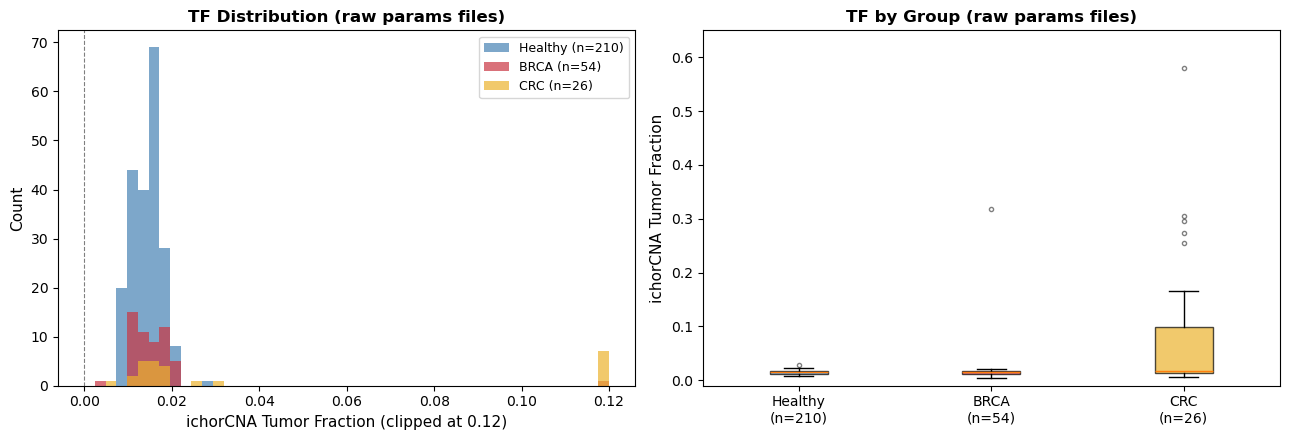

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram of TF values
ax = axes[0]
bins = np.linspace(0, 0.12, 50)
ax.hist(healthy_tf.clip(upper=0.12), bins=bins, alpha=0.7, label=f'Healthy (n={len(healthy_tf)})', color='steelblue')
ax.hist(brca_tf.clip(upper=0.12),    bins=bins, alpha=0.7, label=f'BRCA (n={len(brca_tf)})',   color='#CA3542')
ax.hist(crc_tf.clip(upper=0.12),     bins=bins, alpha=0.7, label=f'CRC (n={len(crc_tf)})',    color='#ECB22E')
ax.set_xlabel('ichorCNA Tumor Fraction (clipped at 0.12)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('TF Distribution (raw params files)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Right: box / strip plot
ax2 = axes[1]
data_groups = [healthy_tf.values, brca_tf.values, crc_tf.values]
labels = [f'Healthy\n(n={len(healthy_tf)})', f'BRCA\n(n={len(brca_tf)})', f'CRC\n(n={len(crc_tf)})']
colors = ['steelblue', '#CA3542', '#ECB22E']
bp = ax2.boxplot(data_groups, patch_artist=True, showfliers=True,
                 flierprops=dict(marker='o', markersize=3, alpha=0.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylabel('ichorCNA Tumor Fraction', fontsize=11)
ax2.set_title('TF by Group (raw params files)', fontsize=12, fontweight='bold')
ax2.set_ylim(-0.01, 0.65)

plt.tight_layout()
# plt.savefig('figures/ichorcna_tf_distribution_raw.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Precision at 95% specificity (study cohort, raw TF values)

In [10]:
study_cancer = study_df[study_df['disease'].isin(['Breast cancer', 'Colorectal cancer'])]
study_healthy = study_df[study_df['disease'] == 'Healthy']
eval_df = pd.concat([study_cancer, study_healthy], ignore_index=True)

y      = (eval_df['disease'] != 'Healthy').astype(int).values
scores = eval_df['ichorcna_tf_raw'].values

# Drop NaN
valid = ~np.isnan(scores)
y, scores = y[valid], scores[valid]

fpr, tpr, thresholds = roc_curve(y, scores)
roc_auc = auc(fpr, tpr)
specificity = 1 - fpr

# Threshold at 95% specificity
idx_95 = np.where(specificity >= 0.95)[0]
threshold_95 = float(thresholds[idx_95[-1]])

y_pred = (scores >= threshold_95).astype(int)
cm = confusion_matrix(y, y_pred)
tn, fp, fn, tp = cm.ravel()

precision_val  = tp / (tp + fp)  if (tp + fp)  > 0 else 0
recall_val     = tp / (tp + fn)  if (tp + fn)  > 0 else 0
specificity_val= tn / (tn + fp)  if (tn + fp)  > 0 else 0

print(f'AUC (BRCA+CRC vs Healthy, raw TF): {roc_auc:.3f}')
print(f'95% specificity threshold:         {threshold_95:.5f}')
print()
print(f'Confusion matrix at 95% spec threshold:')
print(f'  TN={tn}, FP={fp}, FN={fn}, TP={tp}')
print(f'  Precision:   {precision_val:.3f}  (of predicted positives, fraction truly cancer)')
print(f'  Recall:      {recall_val:.3f}  (sensitivity — fraction of cancer detected)')
print(f'  Specificity: {specificity_val:.3f}  (actual specificity on full cohort, not just train set)')
print()
print('Healthy samples ABOVE threshold (false positives):', fp)
print('Cancer samples  ABOVE threshold (true positives):', tp)
print()
fp_ids = eval_df[valid][y_pred.astype(bool) & (y == 0)]['ID'].values
print('False positive sample IDs:', fp_ids)
fp_detail = study_df[study_df['ID'].isin(fp_ids)][['ID', 'disease', 'ichorcna_tf_raw']]
print(fp_detail.to_string())

AUC (BRCA+CRC vs Healthy, raw TF): 0.596
95% specificity threshold:         0.02001

Confusion matrix at 95% spec threshold:
  TN=203, FP=7, FN=65, TP=15
  Precision:   0.682  (of predicted positives, fraction truly cancer)
  Recall:      0.188  (sensitivity — fraction of cancer detected)
  Specificity: 0.967  (actual specificity on full cohort, not just train set)

Healthy samples ABOVE threshold (false positives): 7
Cancer samples  ABOVE threshold (true positives): 15

False positive sample IDs: ['EE87984' 'EE87996' 'EE88047' 'EE88144' 'EE88145' 'EE88154' 'EE88174']
          ID  disease  ichorcna_tf_raw
91   EE87984  Healthy          0.02047
103  EE87996  Healthy          0.02111
154  EE88047  Healthy          0.02007
251  EE88144  Healthy          0.02047
252  EE88145  Healthy          0.02199
261  EE88154  Healthy          0.02152
281  EE88174  Healthy          0.02837


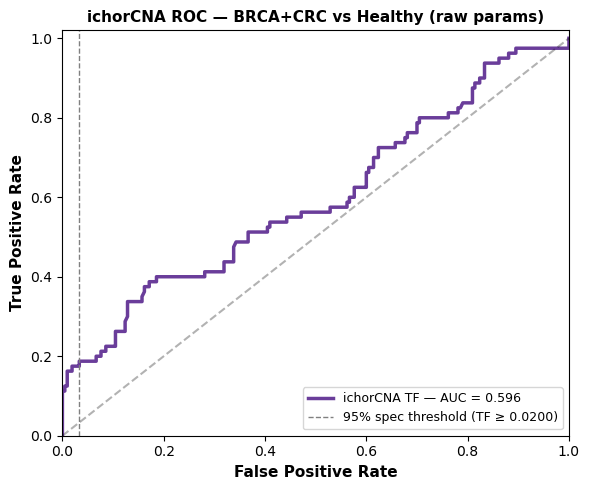

In [12]:
# ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#6A3D9A', linewidth=2.5,
        label=f'ichorCNA TF — AUC = {roc_auc:.3f}')
ax.axvline(1 - specificity_val, color='gray', linestyle='--', linewidth=1,
           label=f'95% spec threshold (TF ≥ {threshold_95:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.set_title('ichorCNA ROC — BRCA+CRC vs Healthy (raw params)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
# plt.savefig('figures/ichorcna_roc_raw.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Summary of findings

In [13]:
print('=' * 70)
print('AUDIT SUMMARY')
print('=' * 70)
print()
print('1. DUPLICATE BUG IN AGGREGATE CSV')
print(f'   cris_metadata.csv:              {len(metadata)} samples ({(metadata["disease"]=="Healthy").sum()} healthy)')
print(f'   aggregate CSV (with dups):       {len(agg)} rows ({(agg["disease"]=="Healthy").sum()} healthy rows)')
print(f'   Duplicate entries:               {agg["ID"].duplicated().sum()} (all are healthy samples)')
print(f'   => {agg["ID"].duplicated().sum()} healthy samples appear TWICE in the CSV')
print()
print('2. STUDY COHORT')
print(f'   Samples used in nested CV:       {len(study_ids)} (210 healthy + 54 BRCA + 26 CRC)')
print(f'   Samples excluded:                {len(metadata) - len(study_ids)} (52 healthy + other cancer types)')
print(f'   => The 210 vs 262 healthy discrepancy is correct study design, not a bug')
print()
print('3. ichorCNA TF FOR HEALTHY SAMPLES (raw params files)')
print(f'   Healthy samples with TF == 0:    {(healthy_tf == 0).sum()} / {len(healthy_tf)}')
print(f'   Healthy samples with TF > 0:     {(healthy_tf > 0).sum()} / {len(healthy_tf)}')
print(f'   Healthy TF mean:                 {healthy_tf.mean():.4f} (noise floor ~0.015)')
print(f'   => ichorCNA does NOT return TF=0 for healthy samples.')
print(f'      The noise floor is ~0.015, overlapping with most cancer samples.')
print()
print('4. ichorCNA PRECISION AT 95% SPECIFICITY')
print(f'   Threshold:                       {threshold_95:.5f}')
print(f'   True positives (cancer detected): {tp} / {tp+fn} ({tp/(tp+fn)*100:.1f}%)')
print(f'   False positives (healthy flagged): {fp} / {tn+fp} ({fp/(tn+fp)*100:.1f}%)')
print(f'   Precision:                        {precision_val:.3f}')
print(f'   Recall (sensitivity):             {recall_val:.3f}')
print(f'   => Low sensitivity because most BRCA/CRC TF values overlap with healthy.')
print(f'      Precision is moderate-to-high only because SPECIFICITY was fixed at 95%,')
print(f'      but very few cancers are detected (low recall drives poor overall F1).')

AUDIT SUMMARY

1. DUPLICATE BUG IN AGGREGATE CSV
   cris_metadata.csv:              534 samples (262 healthy)
   aggregate CSV (with dups):       550 rows (278 healthy rows)
   Duplicate entries:               16 (all are healthy samples)
   => 16 healthy samples appear TWICE in the CSV

2. STUDY COHORT
   Samples used in nested CV:       290 (210 healthy + 54 BRCA + 26 CRC)
   Samples excluded:                244 (52 healthy + other cancer types)
   => The 210 vs 262 healthy discrepancy is correct study design, not a bug

3. ichorCNA TF FOR HEALTHY SAMPLES (raw params files)
   Healthy samples with TF == 0:    0 / 210
   Healthy samples with TF > 0:     210 / 210
   Healthy TF mean:                 0.0143 (noise floor ~0.015)
   => ichorCNA does NOT return TF=0 for healthy samples.
      The noise floor is ~0.015, overlapping with most cancer samples.

4. ichorCNA PRECISION AT 95% SPECIFICITY
   Threshold:                       0.02001
   True positives (cancer detected): 15 / 80 (18.